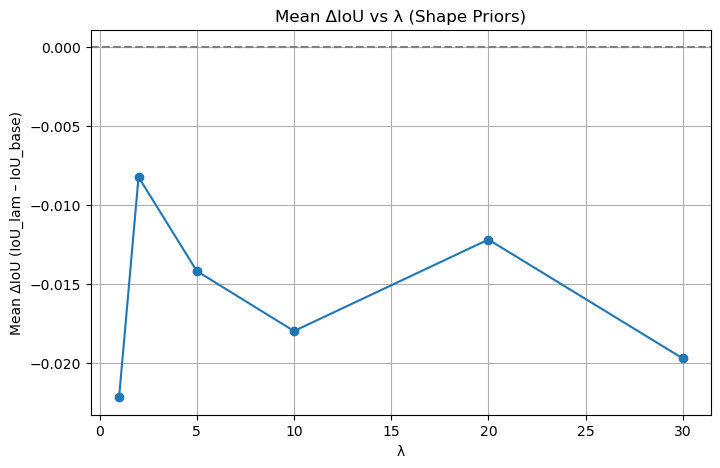

<Figure size 1400x600 with 0 Axes>

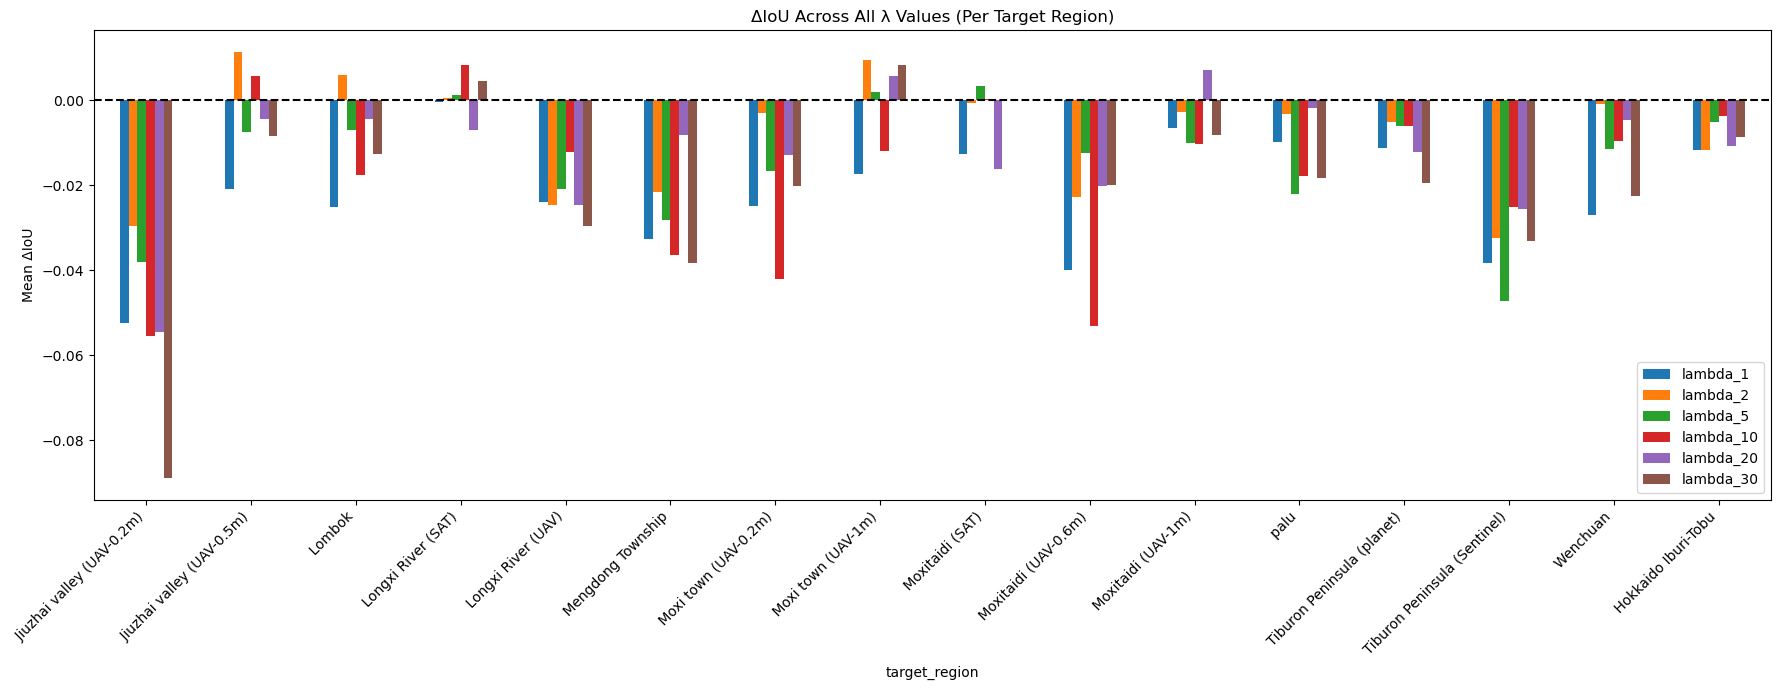

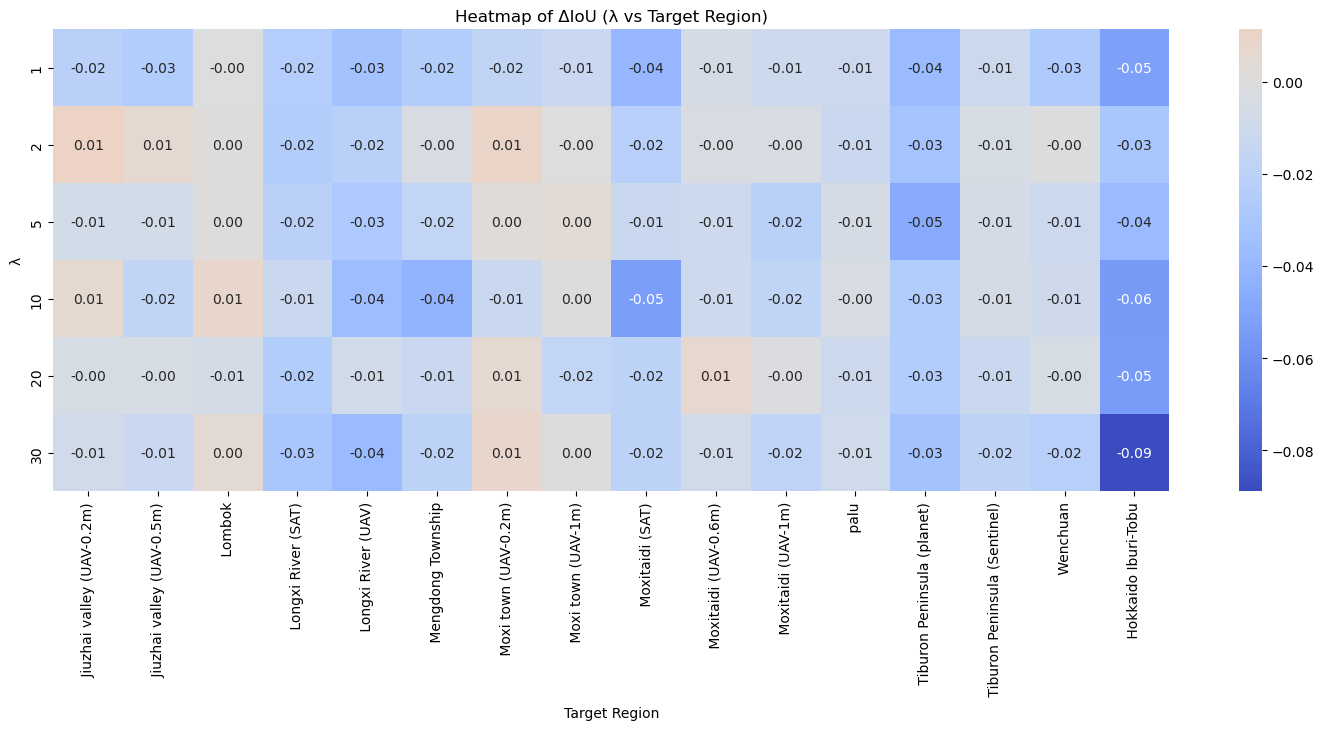

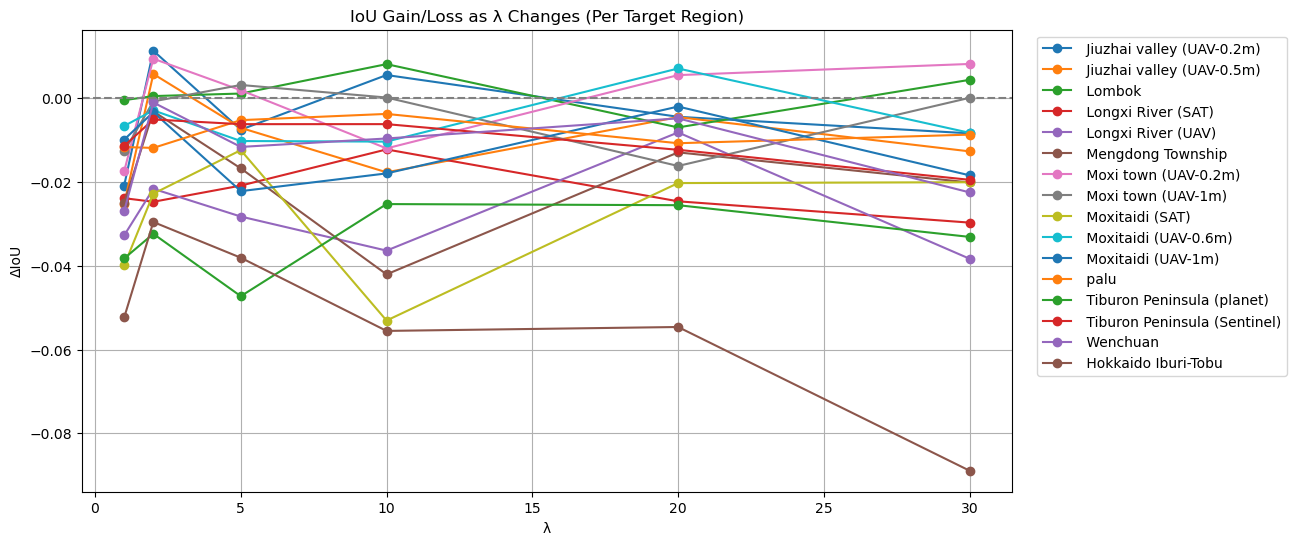

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# Load all CSVs
# ============================
lambda_vals = [1, 2, 5, 10, 20, 30]
dfs = {}

dfs["baseline"] = pd.read_csv("../../results/baseline/final_source_only_100_0.csv")

for lam in lambda_vals:
    dfs[lam] = pd.read_csv(f"../../results/shape_priors/lambda_{lam}.csv")

# ============================
# Compute ΔIoU for each λ
# ============================
delta_tables = {}

for lam in lambda_vals:
    df_lam = dfs[lam]
    df_base = dfs["baseline"]

    merged = df_lam.merge(
        df_base, 
        on=["source_region","target_region"],
        suffixes=("_lam","_base")
    )

    merged["delta_iou"] = merged["iou_lam"] - merged["iou_base"]
    delta_tables[lam] = merged

# ============================
# 1. Mean ΔIoU vs λ
# ============================
mean_deltas = [ delta_tables[lam]["delta_iou"].mean() for lam in lambda_vals ]

plt.figure(figsize=(8,5))
plt.plot(lambda_vals, mean_deltas, marker='o')
plt.axhline(0, ls='--', color='gray')
plt.title("Mean ΔIoU vs λ (Shape Priors)")
plt.xlabel("λ")
plt.ylabel("Mean ΔIoU (IoU_lam – IoU_base)")
plt.grid(True)
plt.show()


# ============================
# 2. Per-target stacked graph
# ============================
plt.figure(figsize=(14,6))
target_order = dfs["baseline"]["target_region"].unique()

plot_data = {
    "target_region": target_order
}

for lam in lambda_vals:
    plot_data[f"lambda_{lam}"] = delta_tables[lam].groupby("target_region")["delta_iou"].mean()

plot_df = pd.DataFrame(plot_data).set_index("target_region")

plot_df.plot(kind="bar", figsize=(18,7))
plt.axhline(0, ls='--', color='black')
plt.title("ΔIoU Across All λ Values (Per Target Region)")
plt.ylabel("Mean ΔIoU")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ============================
# 3. Heatmap: λ vs target region
# ============================
heatmap_df = pd.DataFrame(index=lambda_vals, columns=target_order)

for lam in lambda_vals:
    region_means = delta_tables[lam].groupby("target_region")["delta_iou"].mean()
    for region in target_order:
        heatmap_df.loc[lam, region] = region_means.get(region, 0)

heatmap_df = heatmap_df.astype(float)

plt.figure(figsize=(18,6))
sns.heatmap(heatmap_df, annot=True, fmt=".02f", cmap="coolwarm", center=0)
plt.title("Heatmap of ΔIoU (λ vs Target Region)")
plt.xlabel("Target Region")
plt.ylabel("λ")
plt.show()


# ============================
# 4. Line plot for each target region vs λ
# ============================
plt.figure(figsize=(12,6))

for region in target_order:
    values = [heatmap_df.loc[lam, region] for lam in lambda_vals]
    plt.plot(lambda_vals, values, marker='o', label=region)

plt.axhline(0, ls='--', color='gray')
plt.title("IoU Gain/Loss as λ Changes (Per Target Region)")
plt.xlabel("λ")
plt.ylabel("ΔIoU")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)
plt.show()